In [1]:
# Core libraries
import os
import json
from collections import Counter

# Data handling
import pandas as pd
from datasets import load_dataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter 
# Display settings
pd.set_option('display.max_colwidth', 500)
sns.set(style="whitegrid")


c:\Users\ASUS\Desktop\ING5\Traitement autom\fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

data_dir = "../data" 

# Domains
domains = [
    "phishing",
    "fake_news",
    "political_statements",  
    "product_reviews",
    "job_scams",
    "sms",
    "twitter_rumours"
]

# File names
splits = ["train.jsonl", "validation.jsonl", "test.jsonl"]


# Step 1: Load 

In [3]:
def load_jsonl(filepath):
    """Load a .jsonl file into a pandas DataFrame"""
    data = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)


In [4]:
def load_domain_data(domain, data_dir="../data"):
    """
    Load train, validation, and test JSONL files for a given domain.
    Returns a dict of DataFrames and a combined DataFrame.
    """
    domain_path = os.path.join(data_dir, domain)
    splits = ["train.jsonl", "validation.jsonl", "test.jsonl"]
    dfs = {}
    
    for split in splits:
        path = os.path.join(domain_path, split)
        if os.path.exists(path):
            dfs[split.split(".")[0]] = load_jsonl(path)
        else:
            print(f"⚠️ {split} not found for {domain}")
            dfs[split.split(".")[0]] = pd.DataFrame()
    
    dfs["all"] = pd.concat([df for df in dfs.values() if not df.empty], ignore_index=True)
    return dfs


# Step 2: General summary 

In [5]:
def summarize_domain(domain, data_dir="../data", split="train"):
    """
    Summarize a domain dataset.
    
    Parameters:
        domain (str): Domain name.
        data_dir (str): Path to data directory.
        split (str): "train", "validation", "test", or "all".
    
    Returns:
        dict: summary statistics for the domain and split.
    """
    # Load domain data
    dfs = load_domain_data(domain, data_dir)
    
    if split not in dfs:
        print(f"⚠️ Split '{split}' not found for domain '{domain}'")
        return None
    
    df = dfs[split]
    if df.empty:
        return None
    
    n_samples = len(df)
    n_deceptive = df['label'].sum()
    n_non_deceptive = n_samples - n_deceptive
    avg_len = df['text'].apply(len).mean()
    
    return {
        "domain": domain,
        "split": split,
        "total_samples": n_samples,
        "deceptive": n_deceptive,
        "non_deceptive": n_non_deceptive,
        "avg_text_length": round(avg_len, 2)
    }


In [6]:
summary = []

for domain in domains:
    for split in ["train", "validation", "test", "all"]:
        stats = summarize_domain(domain, split=split)
        if stats:
            summary.append(stats)

summary_df = pd.DataFrame(summary)
summary_df


,domain,split,total_samples,deceptive,non_deceptive,avg_text_length
0,phishing,train,12217,4859,7358,2284.10
1,phishing,validation,1527,607,920,2197.02
2,phishing,test,1528,608,920,2138.11
3,phishing,all,15272,6074,9198,2260.79
4,fake_news,train,16364,7065,9299,3369.66
5,fake_news,validation,2046,884,1162,3387.47
6,fake_news,test,2046,883,1163,3216.64
7,fake_news,all,20456,8832,11624,3356.14
8,political_statements,train,9997,6433,3564,106.47
9,political_statements,validation,1250,804,446,111.21


# Step 3: Analysis 

### 1️⃣Label Distribution

In [7]:
def plot_label_distribution(df, domain_name):
    plt.figure(figsize=(5,4))
    sns.countplot(x='label', data=df)
    plt.xticks([0,1], ['Non-deceptive', 'Deceptive'])
    plt.title(f"Label Distribution - {domain_name}")
    plt.show()

### 2️⃣ Text Length Summary & Histogram

In [8]:
def plot_text_length(df, domain_name):
    df['text_len'] = df['text'].apply(len)
    
    # Summary stats
    print(df['text_len'].describe())
    
    # Histogram
    plt.figure(figsize=(8,4))
    sns.histplot(df['text_len'], bins=50, kde=True)
    plt.title(f"Text Length Distribution - {domain_name}")
    plt.xlabel("Number of characters")
    plt.show()


### 3️⃣ Top Words

In [9]:
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_stopwords = {"com", "www", "https", "email", "click" , "http"}
stop_words |= custom_stopwords

def tokenize(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    return [t for t in tokens if t not in stop_words and len(t) > 2]

def plot_top_words(df, domain_name, top_n=20):
    all_tokens = [token for text in df['text'] for token in tokenize(text)]
    word_counts = Counter(all_tokens)
    common_words = word_counts.most_common(top_n)
    
    words, counts = zip(*common_words)
    plt.figure(figsize=(10,4))
    sns.barplot(x=list(words), y=list(counts))
    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} Meaningful Words - {domain_name}")
    plt.show()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 4️⃣ Word Clouds per Label

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordclouds(df, domain_name):
    deceptive_texts = " ".join(df[df["label"] == 1]["text"].tolist())
    non_deceptive_texts = " ".join(df[df["label"] == 0]["text"].tolist())
    
    wc_deceptive = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(deceptive_texts)
    wc_non_deceptive = WordCloud(width=800, height=400, background_color="white", colormap="Blues").generate(non_deceptive_texts)
    
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    axes[0].imshow(wc_non_deceptive, interpolation="bilinear")
    axes[0].set_title(f"Non-Deceptive - {domain_name}", fontsize=14)
    axes[0].axis("off")
    
    axes[1].imshow(wc_deceptive, interpolation="bilinear")
    axes[1].set_title(f"Deceptive - {domain_name}", fontsize=14)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()


### 5️⃣ Average Word Count per Label

In [11]:
def plot_avg_word_count(df, domain_name):
    df["word_count"] = df["text"].apply(lambda x: len(re.findall(r'\b\w+\b', x)))
    
    avg_wc = df.groupby("label")["word_count"].mean()
    
    plt.figure(figsize=(5,4))
    sns.barplot(x=["Non-deceptive", "Deceptive"], y=avg_wc.values, palette="viridis")
    plt.title(f"Average Word Count per Label - {domain_name}")
    plt.ylabel("Average # of Words")
    plt.show()

### 6️⃣ Vocabulary Richness

In [12]:
def vocab_richness(texts):
    all_words = re.findall(r'\b\w+\b', " ".join(texts).lower())
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if len(all_words) > 0 else 0

def plot_vocab_richness(df, domain_name):
    non_dec_rich = vocab_richness(df[df["label"] == 0]["text"])
    dec_rich = vocab_richness(df[df["label"] == 1]["text"])
    
    plt.figure(figsize=(5,4))
    sns.barplot(x=["Non-deceptive", "Deceptive"], y=[non_dec_rich, dec_rich], palette="coolwarm")
    plt.title(f"Vocabulary Richness per Label - {domain_name}")
    plt.ylabel("Unique Words / Total Words")
    plt.show()
    
    print(f"Vocabulary Richness (Non-deceptive): {non_dec_rich:.4f}")
    print(f"Vocabulary Richness (Deceptive): {dec_rich:.4f}")


### 7️⃣Sentiment Analysis

In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (only once)
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

def compute_sentiment(df):
    """Compute compound sentiment score for each text"""
    df = df.copy()
    df["sentiment"] = df["text"].apply(lambda x: sia.polarity_scores(x)["compound"])
    
    # Summary stats
    print(df.groupby("label")["sentiment"].describe())
    
    # Visualization
    plt.figure(figsize=(6,4))
    sns.boxplot(x="label", y="sentiment", data=df, palette="coolwarm")
    plt.xticks([0,1], ["Non-deceptive", "Deceptive"])
    plt.title("Sentiment Polarity per Label")
    plt.ylabel("Compound Sentiment Score")
    plt.show()
    
    return df

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### 8️⃣Linguistic Features / Style Analysis

In [14]:
import textstat
import numpy as np
import re

def extract_linguistic_features(df):
    """Compute pronouns, punctuation, sentence length, readability"""
    
    def linguistic_features(text):
        features = {}
        text_lower = text.lower()
        
        # Pronouns
        features['i_count'] = text_lower.count(' i ')
        features['we_count'] = text_lower.count(' we ')
        features['you_count'] = text_lower.count(' you ')
        
        # Punctuation
        features['exclamations'] = text.count('!')
        features['questions'] = text.count('?')
        
        # Sentence length
        sentences = re.split(r'[.!?]', text)
        sentences = [s for s in sentences if s.strip()]
        features['avg_sentence_len'] = np.mean([len(s.split()) for s in sentences]) if sentences else 0
        
        # Readability
        features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
        features['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
        
        return features
    
    df_feats = df['text'].apply(linguistic_features).apply(pd.Series)
    df = pd.concat([df, df_feats], axis=1)
    
    # Quick overview
    style_cols = ['i_count','we_count','you_count','exclamations','questions','avg_sentence_len',
                  'flesch_reading_ease','flesch_kincaid_grade']
    
    print(df.groupby('label')[style_cols].mean())
    
    # Boxplots
    plt.figure(figsize=(12,8))
    for i, col in enumerate(style_cols, 1):
        plt.subplot(2,4,i)
        sns.boxplot(x='label', y=col, data=df, palette="Set3")
        plt.xticks([0,1], ['Non-deceptive','Deceptive'])
        plt.title(col)
    plt.tight_layout()
    plt.show()
    
    return df


# step 4: Reporting

In [16]:
def generate_domain_report(domain_name, data_dir="../data"):
    """
    Generate a structured EDA report for a given domain.
    Includes:
    - Label distribution
    - Text length distribution
    - Top meaningful words
    - Wordclouds
    - Average word count per label
    - Vocabulary richness per label
    - Sentiment analysis
    - Linguistic/style features
    """
    
    print(f"\n{'='*60}")
    print(f"DOMAIN: {domain_name.upper()}".center(60))
    print(f"{'='*60}\n")
    
    domain_path = os.path.join(data_dir, domain_name)
    
    # Load data
    train_df = load_jsonl(os.path.join(domain_path, "train.jsonl"))
    val_df = load_jsonl(os.path.join(domain_path, "validation.jsonl"))
    test_df = load_jsonl(os.path.join(domain_path, "test.jsonl"))
    all_df = pd.concat([train_df, val_df, test_df])
    
    print(f"Loaded data:")
    print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}, Total: {all_df.shape}\n")
    
    # --- 1. Label Distribution ---
    print(f"\n{'-'*20} LABEL DISTRIBUTION {'-'*20}\n")
    plot_label_distribution(all_df, domain_name)
    
    # --- 2. Text Length Analysis ---
    print(f"\n{'-'*20} TEXT LENGTH {'-'*20}\n")
    plot_text_length(all_df, domain_name)
    
    # --- 3. Top Words ---
    print(f"\n{'-'*20} TOP 20 MEANINGFUL WORDS {'-'*20}\n")
    plot_top_words(all_df, domain_name)
    
    # --- 4. Word Clouds ---
    print(f"\n{'-'*20} WORD CLOUDS {'-'*20}\n")
    plot_wordclouds(all_df, domain_name)
    
    # --- 5. Average Word Count per Label ---
    print(f"\n{'-'*20} AVERAGE WORD COUNT {'-'*20}\n")
    plot_avg_word_count(all_df, domain_name)
    
    # --- 6. Vocabulary Richness ---
    print(f"\n{'-'*20} VOCABULARY RICHNESS {'-'*20}\n")
    plot_vocab_richness(all_df, domain_name)
    
    # --- 7. Sentiment Analysis ---
    print(f"\n{'-'*20} SENTIMENT ANALYSIS {'-'*20}\n")
    all_df = compute_sentiment(all_df)
    
    # --- 8. Linguistic / Style Features ---
    print(f"\n{'-'*20} LINGUISTIC & STYLE FEATURES {'-'*20}\n")
    all_df = extract_linguistic_features(all_df)
    
    # --- 9. Summary Statistics ---
    print(f"\n{'-'*20} SUMMARY STATISTICS {'-'*20}\n")
    summary = {
        "Domain": domain_name,
        "Total Samples": len(all_df),
        "Deceptive": all_df['label'].sum(),
        "Non-Deceptive": len(all_df) - all_df['label'].sum(),
        "Avg Text Length": round(all_df['text'].apply(len).mean(),2),
        "Avg Sentiment": round(all_df['sentiment'].mean(), 4),
        "Vocab Richness (Non-Deceptive)": round(vocab_richness(all_df[all_df['label']==0]['text']),4),
        "Vocab Richness (Deceptive)": round(vocab_richness(all_df[all_df['label']==1]['text']),4)
    }
    
    for k,v in summary.items():
        print(f"{k:<30}: {v}")
    
    print(f"\n{'='*60}\n")
    
    return all_df, summary



                      DOMAIN: PHISHING                      

Loaded data:
Train: (12217, 2), Validation: (1527, 2), Test: (1528, 2), Total: (15272, 2)


-------------------- LABEL DISTRIBUTION --------------------



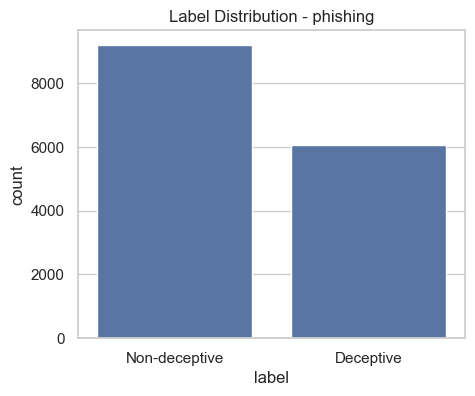


-------------------- TEXT LENGTH --------------------

count     15272.000000
mean       2260.787389
std        9765.023192
min           6.000000
25%         538.000000
50%        1007.000000
75%        2077.000000
max      999999.000000
Name: text_len, dtype: float64


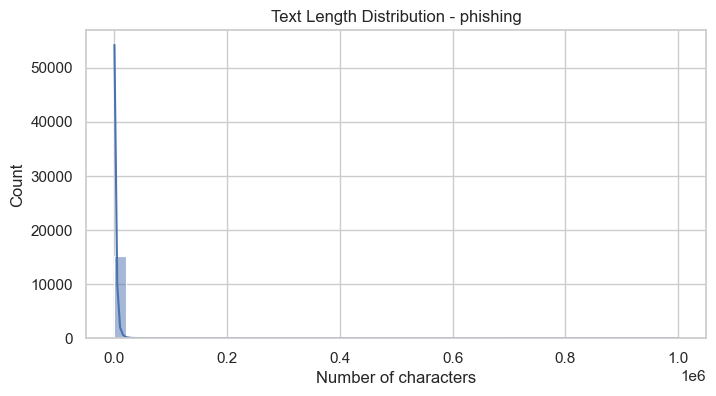


-------------------- TOP 20 MEANINGFUL WORDS --------------------



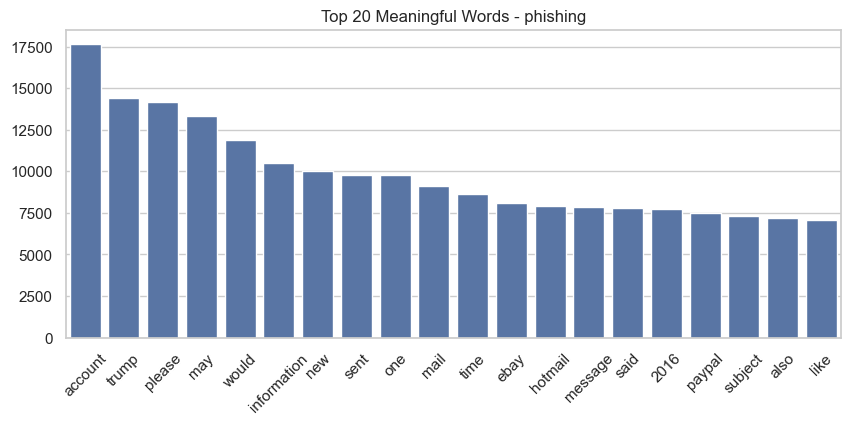


-------------------- WORD CLOUDS --------------------



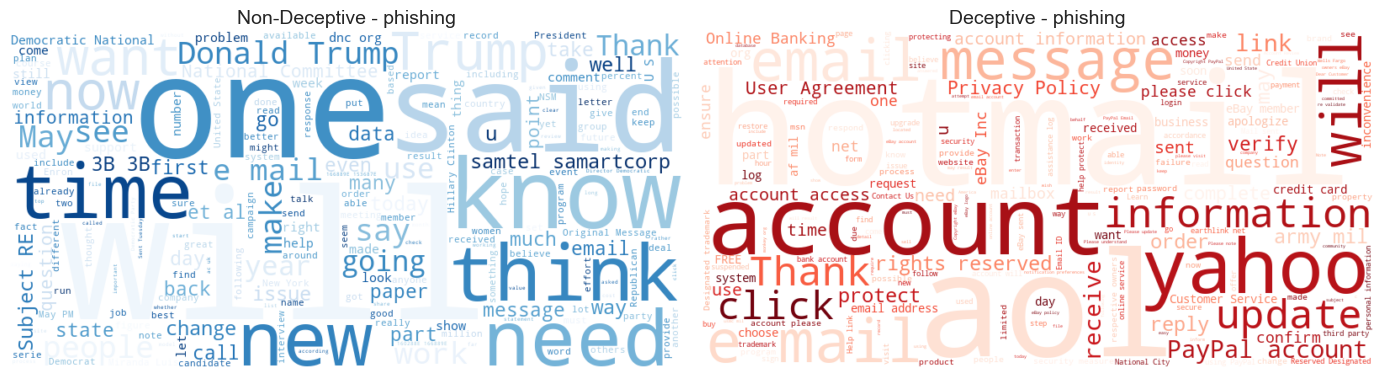


-------------------- AVERAGE WORD COUNT --------------------



C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\4200781053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Non-deceptive", "Deceptive"], y=avg_wc.values, palette="viridis")


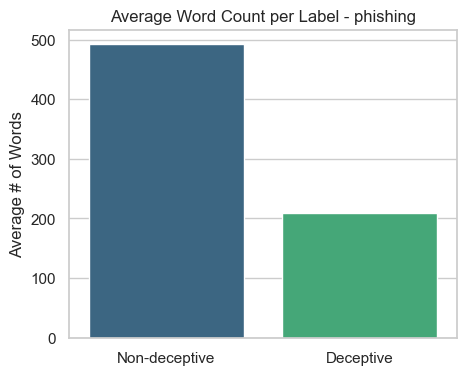


-------------------- VOCABULARY RICHNESS --------------------



C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\755259114.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Non-deceptive", "Deceptive"], y=[non_dec_rich, dec_rich], palette="coolwarm")


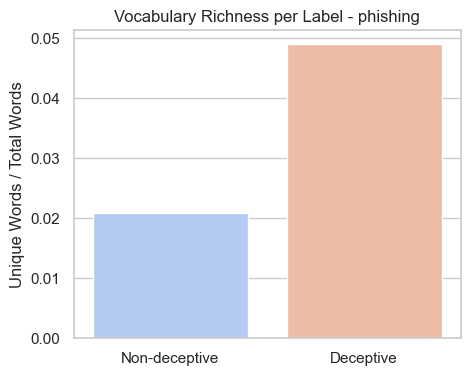

Vocabulary Richness (Non-deceptive): 0.0209
Vocabulary Richness (Deceptive): 0.0490

-------------------- SENTIMENT ANALYSIS --------------------

        count      mean       std     min       25%     50%       75%  max
label                                                                     
0      9198.0  0.553779  0.591968 -1.0000  0.311125  0.8625  0.981575  1.0
1      6074.0  0.658928  0.485634 -0.9952  0.599400  0.8860  0.966000  1.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\4255156970.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="sentiment", data=df, palette="coolwarm")


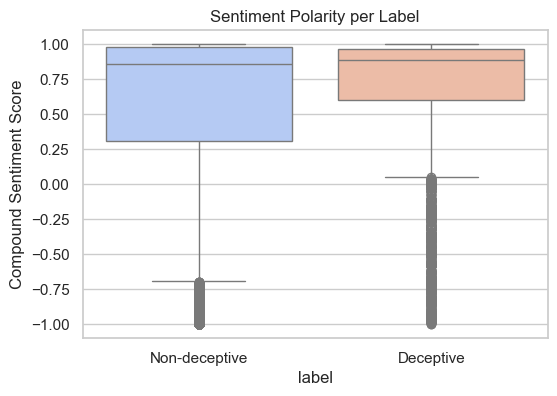


-------------------- LINGUISTIC & STYLE FEATURES --------------------

        i_count  we_count  you_count  exclamations  questions  \
label                                                           
0      3.277886   2.06023   3.052294      1.081213   4.515329   
1      0.503457   1.64241   3.778729      1.184228   0.461640   

       avg_sentence_len  flesch_reading_ease  flesch_kincaid_grade  
label                                                               
0             17.282679            52.684402             10.724811  
1             15.822969            49.451963             10.604885  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\409944978.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette="Set3")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\409944978.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette="Set3")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\409944978.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, palette="Set3")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28616\409944978.py:45: FutureWarning: 


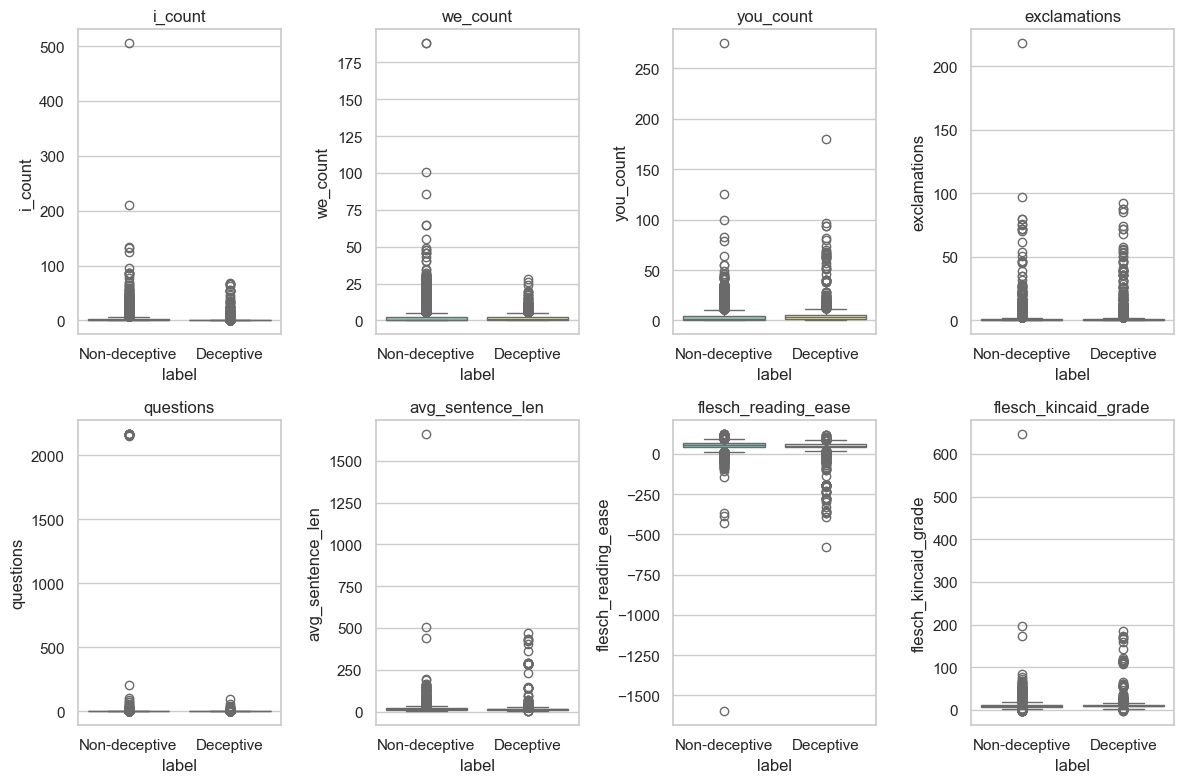


-------------------- SUMMARY STATISTICS --------------------

Domain                        : phishing
Total Samples                 : 15272
Deceptive                     : 6074
Non-Deceptive                 : 9198
Avg Text Length               : 2260.79
Avg Sentiment                 : 0.5956
Vocab Richness (Non-Deceptive): 0.0209
Vocab Richness (Deceptive)    : 0.049




In [17]:
domain = "phishing"
all_df, summary = generate_domain_report(domain)
